# fast-plate-ocr: ajuste fino con placas españolas y colombianas

Adaptado del tutorial oficial
[`tutorial_fine_tune_plate_model.ipynb`](https://github.com/ankandrew/fast-plate-ocr/blob/master/examples/tutorial_fine_tune_plate_model.ipynb)
de [fast-plate-ocr](https://github.com/ankandrew/fast-plate-ocr): preparar el dataset, validarlo, ajustar un modelo
preentrenado, medirlo y exportarlo a **TFLite** (y ONNX).

Diferencias con el tutorial:

* **Datos**: todas las placas que tenemos, españolas (UC3M-LP con los caracteres anonimizados rellenados, de
  `Rellenar_UC3M-LP.ipynb`) y colombianas (`new_plates/plates-ocr-train`), con los mismos repartos de validación y test
  que `TrOCR_Placas.ipynb`.
* **Modelo base**: `cct_s_v2_global`, el recomendado por fast-plate-ocr (el tutorial usa `cct_xs_v1_global`). Está
  preentrenado con placas de más de 65 países; Colombia no está entre ellos.
* **Sin cabeza de país**: el CSV no lleva columna `plate_region` (Colombia no está en la lista de regiones del modelo),
  así que se entrena solo la lectura de la placa.
* **Tamaño de entrada** configurable con `IMG_SIZE` (por defecto 96×192, en lugar de los 64×128 del modelo base). El
  modelo base se adapta al nuevo tamaño interpolando sus *embeddings* de posición, así que conserva su preentrenamiento.
* **Backend**: el entrenamiento usa Keras con PyTorch, que ya funciona con la GPU del contenedor (RTX serie 50); la
  exportación a TFLite necesita TensorFlow y se hace en CPU. El `.keras` es independiente del backend.
* **Línea base** con el modelo preentrenado en ONNX (`LicensePlateRecognizer`): `fast-plate-ocr valid` no admite un
  modelo con cabeza de país y un CSV sin región.

Selecciona el kernel **Python (RF-DETR)**: incluye `fast-plate-ocr[train,onnx]` (ver `env-detr.yml`).

## Configuración

Las órdenes `fast-plate-ocr` se ejecutan con el ejecutable del entorno del kernel, y cada una fija su backend de Keras:
`torch` para entrenar y validar, `tensorflow` (en CPU) para exportar a TFLite.

In [1]:
import os
import sys
import json
import random
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["KERAS_BACKEND"] = "torch"

project_dir = Path.cwd()
if project_dir.name == "notebooks":
    project_dir = project_dir.parent
FPO = Path(sys.executable).parent / "fast-plate-ocr"
RELLENAS_DIR = Path(os.environ.get("PLATES_OCR_FILLED_DIR",
                                   project_dir / "data" / "ocr_vehicles" / "UC3M-LP_ocr_rellenas"))
COLOMBIA_DIR = Path(os.environ.get("COLOMBIA_PLATES_DIR",
                                   project_dir / "data" / "ocr_vehicles" / "new_plates" / "plates-ocr-train"))
DATASET_DIR = Path(os.environ.get("FPO_DATASET_DIR", project_dir / "data" / "ocr_vehicles" / "fast_plate_ocr"))
OUTPUT_DIR = Path(os.environ.get("FPO_OUTPUT_DIR", project_dir / "outputs" / "fast_plate_ocr"))
BASE_DIR = OUTPUT_DIR / "base"
for carpeta in (DATASET_DIR, OUTPUT_DIR, BASE_DIR):
    carpeta.mkdir(parents=True, exist_ok=True)

BASE_MODEL = "cct_s_v2_global"
CROP_PADDING = (0.08, 0.15)  # mismo recorte que el pipeline (Pipeline_Placas_OCR.ipynb)
COLOMBIA_REPEAT = 2          # veces que aparece cada placa colombiana de entrenamiento, como en TrOCR_Placas.ipynb
SEED = 42
# Tamaño (alto, ancho) de entrada al OCR, múltiplos de 4. (64, 128) es el del modelo base; con otro tamaño se adapta
# el modelo base antes de entrenar (ver "Adaptar el modelo base") y se aplica a todo el cuaderno.
IMG_SIZE = (96, 192)

if not FPO.exists():
    raise FileNotFoundError(f"No existe {FPO}: instala fast-plate-ocr[train,onnx] en el entorno del kernel")
print("fast-plate-ocr:", FPO)
print("Dataset:", DATASET_DIR)
print("Salida:", OUTPUT_DIR)

fast-plate-ocr: /opt/conda/envs/detr/bin/fast-plate-ocr
Dataset: /home/mambauser/workspace/data/ocr_vehicles/fast_plate_ocr
Salida: /home/mambauser/workspace/outputs/fast_plate_ocr


Descargamos el modelo `.keras` que vamos a ajustar y sus dos configuraciones: la de la placa (tamaño de entrada,
alfabeto, número de posiciones) y la del modelo (arquitectura). Si `IMG_SIZE` no es el tamaño del modelo base, se
escribe una copia de la configuración de la placa con el nuevo tamaño (`PLATE_CONFIG`); es la que usan todas las celdas
siguientes (validación, aumento, entrenamiento, exportación e inferencia). La original queda en `BASE_PLATE_CONFIG`.

In [2]:
import re
import urllib.request

import yaml

RELEASE = "https://github.com/ankandrew/fast-plate-ocr/releases/download/arg-plates"
for nombre in (f"{BASE_MODEL}.keras", f"{BASE_MODEL}_plate_config.yaml", f"{BASE_MODEL}_model_config.yaml"):
    destino = BASE_DIR / nombre
    if not destino.is_file():
        urllib.request.urlretrieve(f"{RELEASE}/{nombre}", destino)
    print(f"{nombre}: {destino.stat().st_size / 1e6:.1f} MB")

MODEL_KERAS = BASE_DIR / f"{BASE_MODEL}.keras"
BASE_PLATE_CONFIG = BASE_DIR / f"{BASE_MODEL}_plate_config.yaml"
MODEL_CONFIG = BASE_DIR / f"{BASE_MODEL}_model_config.yaml"

base_plate_config = yaml.safe_load(BASE_PLATE_CONFIG.read_text(encoding="utf-8"))
if IMG_SIZE[0] % 4 or IMG_SIZE[1] % 4:
    raise ValueError(f"IMG_SIZE debe ser múltiplo de 4 (el modelo reduce la imagen a 1/4): {IMG_SIZE}")
if tuple(IMG_SIZE) == (base_plate_config["img_height"], base_plate_config["img_width"]):
    PLATE_CONFIG = BASE_PLATE_CONFIG
else:
    # misma configuración con otro img_height/img_width (se conservan los comentarios del YAML)
    PLATE_CONFIG = BASE_DIR / f"{BASE_MODEL}_plate_config_{IMG_SIZE[0]}x{IMG_SIZE[1]}.yaml"
    texto = BASE_PLATE_CONFIG.read_text(encoding="utf-8")
    for clave, valor in (("img_height", IMG_SIZE[0]), ("img_width", IMG_SIZE[1])):
        texto, n = re.subn(rf"(?m)^{clave}:.*$", f"{clave}: {valor}", texto)
        assert n == 1, clave
    PLATE_CONFIG.write_text(texto, encoding="utf-8")

plate_config = yaml.safe_load(PLATE_CONFIG.read_text(encoding="utf-8"))
ALFABETO, PAD = plate_config["alphabet"], plate_config["pad_char"]
print("Configuración de la placa:", PLATE_CONFIG.name)
print({k: plate_config[k] for k in ("max_plate_slots", "alphabet", "pad_char", "img_height", "img_width",
                                    "keep_aspect_ratio", "image_color_mode")})

cct_s_v2_global.keras: 17.7 MB
cct_s_v2_global_plate_config.yaml: 0.0 MB
cct_s_v2_global_model_config.yaml: 0.0 MB
{'max_plate_slots': 10, 'alphabet': '0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ_', 'pad_char': '_', 'img_height': 64, 'img_width': 128, 'keep_aspect_ratio': False, 'image_color_mode': 'rgb'}


## Preparar el dataset

fast-plate-ocr espera recortes de la placa y un CSV con `image_path` (relativa al CSV) y `plate_text`:

* **Españolas**: de `UC3M-LP_ocr_rellenas` (recortes con margen extra y la caja de la placa), se recorta la placa con
  `CROP_PADDING`, el mismo margen que aplica el pipeline a las cajas del detector. Se mantienen sus particiones
  `train`, `validation` y `test`.
* **Colombianas**: ya son recortes de la placa. Las etiquetas se pasan a mayúsculas y se descartan las que no siguen el
  formato colombiano (`AAA000` o `AAA00A`). Las placas que el repositorio repite entre `train` y `valid` se quedan en
  entrenamiento, y el resto de `valid` se reparte por placa entre validación y test (igual que en `TrOCR_Placas.ipynb`).

Se escriben `train.csv` (con las colombianas repetidas), `train_unicas.csv` (sin repetir, para validar y ver
estadísticas), `val.csv` y `test.csv`, además de `val_<fuente>.csv` y `test_<fuente>.csv` para medir cada
fuente por separado. Las imágenes se copian a `DATASET_DIR`, así que el dataset es autocontenido. Si ya existe, se
reutiliza; para regenerarlo, borra la carpeta.

In [3]:
def ampliar_caja(caja, padding, ancho, alto):
    x0, y0, x1, y1 = caja
    pad_x, pad_y = (x1 - x0) * padding[0], (y1 - y0) * padding[1]
    return (max(0, int(x0 - pad_x)), max(0, int(y0 - pad_y)),
            min(ancho, int(np.ceil(x1 + pad_x))), min(alto, int(np.ceil(y1 + pad_y))))


def preparar_espanolas():
    filas = []
    for split, nombre in (("train", "train"), ("validation", "val"), ("test", "test")):
        frame = pd.read_csv(RELLENAS_DIR / f"{split}.csv", dtype={"text": str})
        destino = DATASET_DIR / "uc3m" / nombre
        destino.mkdir(parents=True, exist_ok=True)
        for fila in frame.itertuples():
            ruta = f"uc3m/{nombre}/{Path(fila.file_name).name}"
            if not (DATASET_DIR / ruta).is_file():
                with Image.open(RELLENAS_DIR / "image" / fila.file_name) as imagen:
                    imagen = imagen.convert("RGB")
                    imagen.crop(ampliar_caja((fila.x0, fila.y0, fila.x1, fila.y1), CROP_PADDING,
                                             imagen.width, imagen.height)).save(DATASET_DIR / ruta, quality=95)
            filas.append({"image_path": ruta, "plate_text": fila.text, "split": nombre, "fuente": "uc3m"})
    return pd.DataFrame(filas)


def preparar_colombianas():
    frames = []
    for split in ("train", "valid"):
        frame = pd.read_csv(COLOMBIA_DIR / f"{split}_annotations.csv", dtype=str)
        frame["text"] = frame["plate_text"].str.strip().str.upper()
        frame["split_original"] = split
        frames.append(frame)
    colombia = pd.concat(frames, ignore_index=True)
    validas = colombia["text"].str.fullmatch(r"[A-Z]{3}[0-9]{2}[0-9A-Z]")
    print("Colombianas descartadas por formato:", colombia.loc[~validas, "text"].tolist())
    colombia = colombia[validas]
    en_train = set(colombia.loc[colombia["split_original"] == "train", "text"])
    placas_valid = sorted(set(colombia.loc[(colombia["split_original"] == "valid")
                                           & ~colombia["text"].isin(en_train), "text"]))
    random.Random(SEED).shuffle(placas_valid)
    placas_test = set(placas_valid[:len(placas_valid) // 2])
    placas_val = set(placas_valid[len(placas_valid) // 2:])
    filas = []
    for fila in colombia.itertuples():
        nombre = "test" if fila.text in placas_test else "val" if fila.text in placas_val else "train"
        ruta = f"colombia/{fila.split_original}/{Path(fila.image_path).name}"
        (DATASET_DIR / ruta).parent.mkdir(parents=True, exist_ok=True)
        if not (DATASET_DIR / ruta).is_file():
            shutil.copy(COLOMBIA_DIR / fila.image_path, DATASET_DIR / ruta)
        filas.append({"image_path": ruta, "plate_text": fila.text, "split": nombre, "fuente": "colombia"})
    return pd.DataFrame(filas)


def escribir(frame, nombre):
    frame[["image_path", "plate_text"]].to_csv(DATASET_DIR / nombre, index=False)


if not (DATASET_DIR / "dataset.csv").is_file():
    dataset = pd.concat([preparar_espanolas(), preparar_colombianas()], ignore_index=True)
    dataset.to_csv(DATASET_DIR / "dataset.csv", index=False)
dataset = pd.read_csv(DATASET_DIR / "dataset.csv", dtype=str)

invalidas = dataset[~dataset["plate_text"].apply(lambda t: len(t) <= plate_config["max_plate_slots"]
                                                  and all(c in ALFABETO and c != PAD for c in t))]
if len(invalidas):
    raise ValueError(f"Etiquetas fuera del alfabeto o demasiado largas: {invalidas['plate_text'].tolist()[:10]}")

entrenamiento = dataset[dataset["split"] == "train"]
escribir(entrenamiento, "train_unicas.csv")  # sin repeticiones, para validar y ver estadísticas
entrenamiento = pd.concat([entrenamiento[entrenamiento["fuente"] == "uc3m"]]
                          + [entrenamiento[entrenamiento["fuente"] == "colombia"]] * COLOMBIA_REPEAT)
escribir(entrenamiento.sample(frac=1, random_state=SEED), "train.csv")
for split in ("val", "test"):
    escribir(dataset[dataset["split"] == split], f"{split}.csv")
    for fuente in ("uc3m", "colombia"):
        escribir(dataset[(dataset["split"] == split) & (dataset["fuente"] == fuente)], f"{split}_{fuente}.csv")

TRAIN_CSV, VAL_CSV, TEST_CSV = DATASET_DIR / "train.csv", DATASET_DIR / "val.csv", DATASET_DIR / "test.csv"
TRAIN_UNICAS_CSV = DATASET_DIR / "train_unicas.csv"
print(pd.crosstab(dataset["fuente"], dataset["split"]))
print("Filas de train.csv (colombianas x", COLOMBIA_REPEAT, "):", len(entrenamiento))
print("Placas de validación/test que también están en entrenamiento:",
      len(set(dataset.loc[dataset["split"] != "train", "plate_text"])
          & set(dataset.loc[dataset["split"] == "train", "plate_text"])))

Colombianas descartadas por formato: ['OYG6877', 'WHV4291', 'CQW5891', 'PEO9599']
split     test  train  val
fuente                    
colombia    47    798   48
uc3m       432   1620  181
Filas de train.csv (colombianas x 2 ): 3216
Placas de validación/test que también están en entrenamiento: 0


## Inspeccionar el dataset

Validamos las anotaciones con las herramientas de fast-plate-ocr: imágenes que faltan o no se pueden leer, caracteres
fuera del alfabeto y textos demasiado largos.

In [4]:
!{FPO} validate-dataset --annotations-file {TRAIN_UNICAS_CSV} --plate-config-file {PLATE_CONFIG}

  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2418/2418 Scanning imagescanning imagesmages

 Validation Summary 
┌──────────┬───────┐
│ Category │ Count │
├──────────┼───────┤
│ Errors   │     0 │
│ Warnings │     0 │
└──────────┴───────┘


In [5]:
!{FPO} validate-dataset --annotations-file {VAL_CSV} --plate-config-file {PLATE_CONFIG}

  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229/229 Scanning images Scanning images

 Validation Summary 
┌──────────┬───────┐
│ Category │ Count │
├──────────┼───────┤
│ Errors   │     0 │
│ Warnings │     0 │
└──────────┴───────┘


Estadísticas del conjunto de entrenamiento: longitudes, caracteres más frecuentes y tamaños de imagen.

In [6]:
!{FPO} dataset-stats --annotations {TRAIN_UNICAS_CSV} --plate-config-file {PLATE_CONFIG}

┌─────────────────────────── Dataset Statistics ───────────────────────────┐
│                       Plate Lengths                                      │
│          ╷      ╷      ╷      ╷      ╷      ╷      ╷                     │
│    count │ mean │  std │  min │  max │   5% │  50% │  95%                │
│  ════════╪══════╪══════╪══════╪══════╪══════╪══════╪═════                │
│  2418.00 │ 6.67 │ 0.47 │ 6.00 │ 7.00 │ 6.00 │ 7.00 │ 7.00                │
│          ╵      ╵      ╵      ╵      ╵      ╵      ╵                     │
│                              Image Height                                │
│          ╷        ╷        ╷       ╷         ╷       ╷        ╷          │
│    count │   mean │    std │   min │     max │    5% │    50% │    95%   │
│  ════════╪════════╪════════╪═══════╪═════════╪═══════╪════════╪═══════   │
│  2418.00 │ 172.27 │ 125.49 │ 20.00 │ 1753.00 │ 48.00 │ 152.00 │ 344.15   │
│          ╵        ╵        ╵       ╵         ╵       ╵        ╵          │

## Preparar el entrenamiento

Lo que verá el modelo: el aumento de datos por defecto sobre algunas imágenes de entrenamiento.

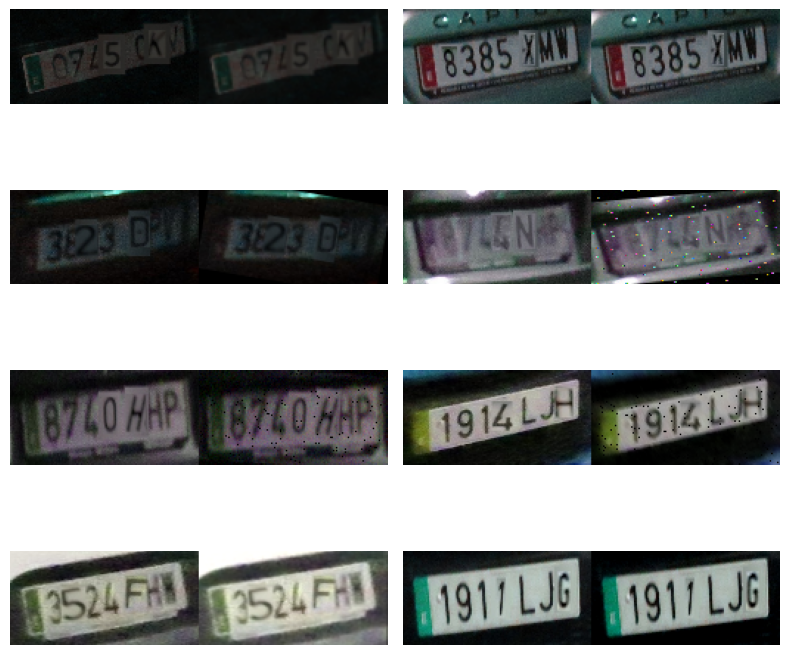

In [7]:
%matplotlib inline
%run -m fast_plate_ocr.cli.visualize_augmentation -- \
      --img-dir {DATASET_DIR / "uc3m" / "train"} \
      --columns 2 --rows 4 --show-original --num-images 8 \
      --plate-config-file {PLATE_CONFIG}

Como en el tutorial, definimos un aumento propio con [albumentations](https://albumentations.ai): el mismo pipeline del
tutorial más una **reducción de resolución** (`Downscale`), porque en la app las placas que encuentra el detector suelen
medir entre 60 y 200 píxeles de ancho y los recortes de UC3M-LP son mucho mayores.

In [8]:
import albumentations as A
import cv2

AUGMENTATION = OUTPUT_DIR / "custom_augmentation.yaml"
A.save(
    A.Compose(
        [
            A.Affine(translate_percent=(-0.02, 0.02), scale=(0.75, 1.10), rotate=(-15, 15),
                     border_mode=cv2.BORDER_CONSTANT, fill=(0, 0, 0), shear=(0.0, 0.0), p=0.75),
            A.RandomBrightnessContrast(brightness_limit=0.10, contrast_limit=0.10, p=0.5),
            A.OneOf(
                [
                    A.HueSaturationValue(hue_shift_limit=5, sat_shift_limit=10, val_shift_limit=10, p=0.7),
                    A.RGBShift(r_shift_limit=10, g_shift_limit=10, b_shift_limit=10, p=0.3),
                ],
                p=0.3,
            ),
            A.RandomGamma(gamma_limit=(95, 105), p=0.20),
            A.ToGray(p=0.05),
            A.Downscale(scale_range=(0.35, 0.8), p=0.3),
            A.OneOf(
                [
                    A.GaussianBlur(sigma_limit=(0.2, 0.5), p=0.5),
                    A.MotionBlur(blur_limit=(3, 3), p=0.5),
                ],
                p=0.2,
            ),
            A.OneOf(
                [
                    A.GaussNoise(std_range=(0.01, 0.03), p=0.2),
                    A.MultiplicativeNoise(multiplier=(0.98, 1.02), p=0.1),
                    A.ISONoise(intensity=(0.005, 0.02), p=0.1),
                    A.ImageCompression(quality_range=(55, 90), p=0.1),
                ],
                p=0.3,
            ),
            A.OneOf(
                [
                    A.CoarseDropout(num_holes_range=(1, 14), hole_height_range=(1, 5), hole_width_range=(1, 5), p=0.2),
                    A.PixelDropout(dropout_prob=0.02, p=0.3),
                    A.GridDropout(ratio=0.3, fill="random", p=0.3),
                ],
                p=0.5,
            ),
        ]
    ),
    filepath_or_buffer=str(AUGMENTATION),
    data_format="yaml",
)
print("Aumento guardado en", AUGMENTATION)

Aumento guardado en /home/mambauser/workspace/outputs/fast_plate_ocr/custom_augmentation.yaml


/opt/conda/envs/detr/lib/python3.11/site-packages/albumentations/core/serialization.py:185: UserWarning: Argument(s) 'approximation, noise_params, noise_type, spatial_mode' are not valid for transform RGBShift
  return cls(**args)


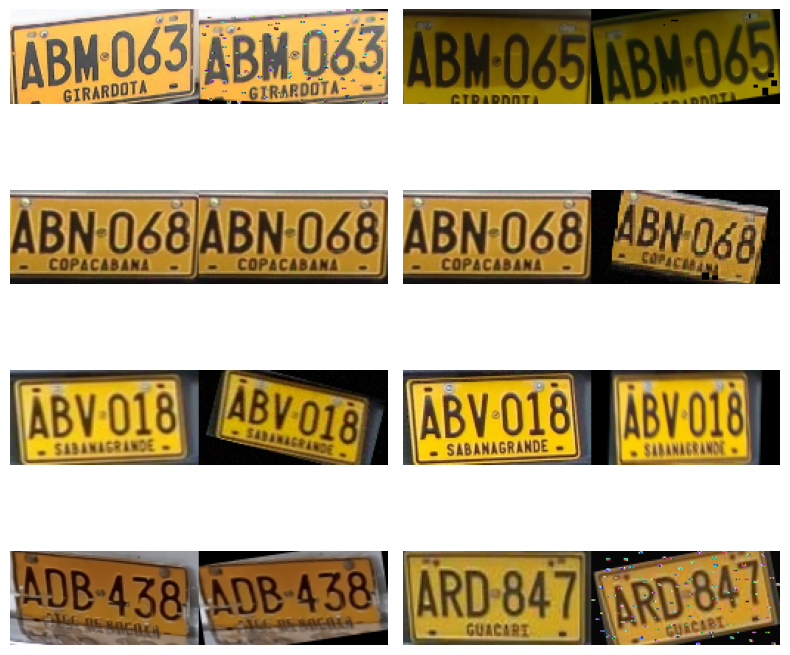

In [9]:
%run -m fast_plate_ocr.cli.visualize_augmentation -- \
      --img-dir {DATASET_DIR / "colombia" / "train"} \
      --columns 2 --rows 4 --show-original --num-images 8 \
      --plate-config-file {PLATE_CONFIG} \
      --augmentation-path {AUGMENTATION}

## Métricas y línea base

Dos métricas, calculadas igual para todos los modelos:

* **Placa exacta** (`plate_acc`): la lectura coincide entera con la etiqueta. Es la métrica estricta de fast-plate-ocr.
* **Caracteres**: porcentaje de caracteres de la etiqueta acertados en su posición.

Antes de entrenar medimos el modelo preentrenado (su versión ONNX, con `LicensePlateRecognizer`) en test, por fuente.

In [10]:
from fast_plate_ocr import LicensePlateRecognizer


def metricas(predicciones, etiquetas):
    predicciones, etiquetas = list(predicciones), list(etiquetas)
    placas = np.mean([p == e for p, e in zip(predicciones, etiquetas)])
    aciertos = sum(sum(a == b for a, b in zip(p, e)) for p, e in zip(predicciones, etiquetas))
    return {"placas": len(etiquetas), "placa_exacta": round(float(placas), 4),
            "caracteres": round(aciertos / sum(len(e) for e in etiquetas), 4)}


def evaluar(leer, nombre):
    filas = {}
    for fuente in ("uc3m", "colombia"):
        frame = pd.read_csv(DATASET_DIR / f"test_{fuente}.csv", dtype=str)
        filas[(nombre, fuente)] = metricas(leer([str(DATASET_DIR / r) for r in frame["image_path"]]), frame["plate_text"])
    frame = pd.read_csv(TEST_CSV, dtype=str)
    filas[(nombre, "todas")] = metricas(leer([str(DATASET_DIR / r) for r in frame["image_path"]]), frame["plate_text"])
    return filas


preentrenado = LicensePlateRecognizer("cct-s-v2-global-model", device="cpu")
resultados = evaluar(lambda rutas: [p.plate for p in preentrenado.run(rutas)], "preentrenado")
pd.DataFrame(resultados)

preentrenado                   
                     uc3m colombia     todas
placas           432.0000  47.0000  479.0000
placa_exacta       0.8542   0.9362    0.8622
caracteres         0.9537   0.9823    0.9561

## Adaptar el modelo base a `IMG_SIZE`

El modelo divide la imagen en parches (la reduce a 1/4 en cada lado: una reducción 2× en las primeras convoluciones y
parches de 2×2) y suma a cada parche un *embedding* de posición aprendido. Es la única capa que depende del tamaño:
a 64×128 hay 16×32 = 512 posiciones y a 96×192, 24×48 = 1.152. El resto (convoluciones, transformer y lectura de las 10
posiciones) no cambia.

Si el tamaño cambia, se construye el modelo con la nueva configuración, se cargan todos los pesos del modelo base y la
tabla de posiciones se **interpola** (bicúbica) de la rejilla original a la nueva, en lugar de dejarla aleatoria como
haría `train`. Se guarda como `.keras` y es el punto de partida del entrenamiento (`WEIGHTS_KERAS`).

Como comprobación, antes de entrenar se leen las placas de validación con el modelo base (64×128) y con el adaptado
(`IMG_SIZE`): deben leer casi igual.

In [ ]:
import torch
from fast_plate_ocr.core.process import read_and_resize_plate_image
from fast_plate_ocr.train.model.config import load_plate_config_from_yaml
from fast_plate_ocr.train.model.model_builders import build_model
from fast_plate_ocr.train.model.model_schema import load_model_config_from_yaml
from fast_plate_ocr.train.utilities.utils import load_keras_model

base_cfg = load_plate_config_from_yaml(BASE_PLATE_CONFIG)
nuevo_cfg = load_plate_config_from_yaml(PLATE_CONFIG)
modelo_base = load_keras_model(MODEL_KERAS, base_cfg)

if PLATE_CONFIG == BASE_PLATE_CONFIG:
    WEIGHTS_KERAS = MODEL_KERAS
    modelo_adaptado = modelo_base
else:
    WEIGHTS_KERAS = BASE_DIR / f"{BASE_MODEL}_{IMG_SIZE[0]}x{IMG_SIZE[1]}.keras"
    modelo_adaptado = build_model(load_model_config_from_yaml(MODEL_CONFIG), nuevo_cfg, enable_region_head=True)
    modelo_adaptado.load_weights(MODEL_KERAS, skip_mismatch=True)  # todo salvo pos_emb, que cambia de tamaño
    tabla = modelo_base.get_layer("pos_emb").get_weights()[0]
    rejilla_base = (base_cfg.img_height // 4, base_cfg.img_width // 4)
    rejilla_nueva = (IMG_SIZE[0] // 4, IMG_SIZE[1] // 4)
    assert tabla.shape[0] == rejilla_base[0] * rejilla_base[1], tabla.shape
    posiciones = torch.from_numpy(tabla).reshape(1, *rejilla_base, -1).permute(0, 3, 1, 2)
    posiciones = torch.nn.functional.interpolate(posiciones, size=rejilla_nueva, mode="bicubic", align_corners=False)
    modelo_adaptado.get_layer("pos_emb").set_weights(
        [posiciones.permute(0, 2, 3, 1).reshape(-1, tabla.shape[1]).numpy()])
    modelo_adaptado.save(WEIGHTS_KERAS)
    print(f"pos_emb: {rejilla_base} -> {rejilla_nueva}; modelo adaptado en {WEIGHTS_KERAS}")


def leer_keras(modelo, cfg, rutas):
    imagenes = np.stack([
        read_and_resize_plate_image(str(ruta), img_height=cfg.img_height, img_width=cfg.img_width,
                                    image_color_mode=cfg.image_color_mode, keep_aspect_ratio=cfg.keep_aspect_ratio,
                                    interpolation_method=cfg.interpolation, padding_color=cfg.padding_color)
        for ruta in rutas])
    salida = modelo.predict(imagenes, verbose=0)
    probabilidades = salida["plate"] if isinstance(salida, dict) else salida[0] if isinstance(salida, (list, tuple)) else salida
    return ["".join(ALFABETO[i] for i in fila.argmax(-1)).replace(PAD, "") for fila in probabilidades]


validacion = pd.read_csv(VAL_CSV, dtype=str)
rutas_val = [DATASET_DIR / r for r in validacion["image_path"]]
lecturas_base = leer_keras(modelo_base, base_cfg, rutas_val)
lecturas_adaptado = leer_keras(modelo_adaptado, nuevo_cfg, rutas_val)
print(f"Validación ({len(validacion)} placas), antes de entrenar:")
print(f"  modelo base {base_cfg.img_height}x{base_cfg.img_width}: {metricas(lecturas_base, validacion['plate_text'])}")
print(f"  adaptado {nuevo_cfg.img_height}x{nuevo_cfg.img_width}: {metricas(lecturas_adaptado, validacion['plate_text'])}")
print(f"  misma lectura en el {np.mean([a == b for a, b in zip(lecturas_base, lecturas_adaptado)]):.1%} de las placas")
del modelo_base, modelo_adaptado

## Entrenar

Ajuste fino con los hiperparámetros del tutorial (AdamW, `lr` 0.0005, `weight_decay` 0.0005, sin *label smoothing*,
batch de 32), el aumento anterior y *early stopping* sobre `val_plate_acc`. Con más datos que el tutorial se dejan más
épocas como máximo. Keras usa PyTorch y, si la hay, la GPU. Cada ejecución se guarda en una carpeta con fecha dentro de
`OUTPUT_DIR / "trained"`, con `best.keras` (mejor época en validación), `last.keras`, las configuraciones y
`training_log.csv`.

Se parte de `WEIGHTS_KERAS`, el modelo base adaptado a `IMG_SIZE`. Con 96×192 hay 2,25 veces más parches que con 64×128,
así que cada época tarda unas 2–3 veces más; si falta memoria de GPU, usa `BATCH_SIZE = 16`.

In [11]:
EPOCHS = 100
EARLY_STOPPING_PATIENCE = 20
BATCH_SIZE = 32
TRAINED_DIR = OUTPUT_DIR / "trained"

!KERAS_BACKEND=torch {FPO} train \
  --model-config-file {MODEL_CONFIG} \
  --plate-config-file {PLATE_CONFIG} \
  --annotations {TRAIN_CSV} \
  --val-annotations {VAL_CSV} \
  --augmentation-path {AUGMENTATION} \
  --epochs {EPOCHS} \
  --early-stopping-patience {EARLY_STOPPING_PATIENCE} \
  --batch-size {BATCH_SIZE} \
  --workers 4 \
  --output-dir {TRAINED_DIR} \
  --weights-path {WEIGHTS_KERAS} \
  --label-smoothing 0.0 \
  --weight-decay 0.0005 \
  --lr 0.0005 \
  --seed {SEED}



                                 CLI Training Parameters                        
╭─────────────────────────┬─────────────────────────────────────────────────────
│ Parameter               │ Details                                             
├─────────────────────────┼─────────────────────────────────────────────────────
│ model_config_file       │ '/home/mambauser/workspace/outputs/fast_plate_ocr/ba
│ plate_config_file       │ '/home/mambauser/workspace/outputs/fast_plate_ocr/ba
│ annotations             │ '/home/mambauser/workspace/data/ocr_vehicles/fast_pl
│ val_annotations         │ '/home/mambauser/workspace/data/ocr_vehicles/fast_pl
│ validate_dataset        │ 'off'                                               
│ validation_freq         │ 1                                                   
│ augmentation_path       │ '/home/mambauser/workspace/outputs/fast_plate_ocr/cu
│ lr                      │ 0.0005                                              
│ final_lr_factor         

Curvas del entrenamiento de la última ejecución:

Ejecución: 2026-09-29_15-33-44 - épocas: 29
Mejor val_acc: 0.95703125 en la época 9


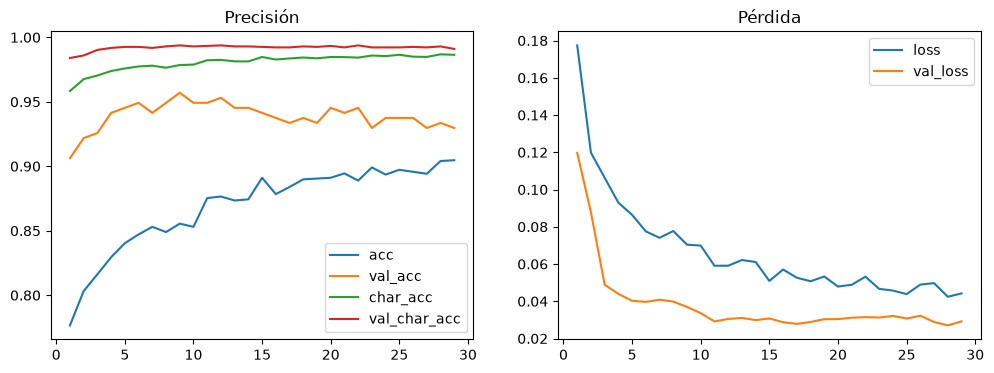

In [12]:
import matplotlib.pyplot as plt

RUN_DIR = sorted(p for p in TRAINED_DIR.iterdir() if (p / "best.keras").is_file())[-1]
BEST_KERAS = RUN_DIR / "best.keras"
RUN_PLATE_CONFIG = RUN_DIR / "plate_config.yaml"
log = pd.read_csv(RUN_DIR / "training_log.csv")
print("Ejecución:", RUN_DIR.name, "- épocas:", len(log))
print("Mejor val_acc:", log["val_acc"].max(), "en la época", int(log.loc[log["val_acc"].idxmax(), "epoch"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for columna in ("acc", "val_acc", "char_acc", "val_char_acc"):
    if columna in log:
        axes[0].plot(log["epoch"] + 1, log[columna], label=columna)
axes[0].set_title("Precisión")
axes[0].legend()
for columna in ("loss", "val_loss"):
    axes[1].plot(log["epoch"] + 1, log[columna], label=columna)
axes[1].set_title("Pérdida")
axes[1].legend()
plt.show()

Validación del mejor modelo Keras con la herramienta de fast-plate-ocr, en test y por fuente:

In [13]:
for nombre in ("test.csv", "test_uc3m.csv", "test_colombia.csv"):
    print("=====", nombre)
    !KERAS_BACKEND=torch {FPO} valid --model {BEST_KERAS} --plate-config-file {RUN_PLATE_CONFIG} --annotations {DATASET_DIR / nombre}

===== test.csv
479/479 ━━━━━━━━━━━━━━━━━━━━ 23s 35ms/step - acc: 0.9353 - char_acc: 0.9923 - len_acc: 1.0000 - loss: 0.1704 - top3_acc: 0.9985
===== test_uc3m.csv
432/432 ━━━━━━━━━━━━━━━━━━━━ 17s 38ms/step - acc: 0.9352 - char_acc: 0.9921 - len_acc: 1.0000 - loss: 0.1717 - top3_acc: 0.9984
===== test_colombia.csv
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - acc: 0.9362 - char_acc: 0.9936 - len_acc: 1.0000 - loss: 0.1592 - top3_acc: 1.0000  


## Exportar

TFLite para la app (entrada fija de batch 1) y ONNX para usarlo con `LicensePlateRecognizer` o en el pipeline. La
exportación a TFLite necesita el backend de TensorFlow; se hace en CPU. fast-plate-ocr comprueba que cada modelo
exportado da las mismas salidas que el Keras:

* el **ONNX** es float32 y debe coincidir (`matches Keras ✔`);
* el **TFLite** se convierte con `Optimize.DEFAULT`, que guarda los pesos en int8 (por eso ocupa ~1,6 MB). Sus
  probabilidades pueden diferir algo más que la tolerancia de la comprobación (`deviates from Keras beyond tolerance`);
  lo que importa es si cambian las lecturas, que se mide abajo comparándolo con el ONNX.

Se copian a `OUTPUT_DIR / "export"` junto con su `plate_config.yaml`.

In [14]:
!CUDA_VISIBLE_DEVICES= KERAS_BACKEND=tensorflow {FPO} export --model {BEST_KERAS} --plate-config-file {RUN_PLATE_CONFIG} --format tflite
!CUDA_VISIBLE_DEVICES= KERAS_BACKEND=tensorflow {FPO} export --model {BEST_KERAS} --plate-config-file {RUN_PLATE_CONFIG} --format onnx --simplify

EXPORT_DIR = OUTPUT_DIR / "export"
EXPORT_DIR.mkdir(exist_ok=True)
TFLITE_PATH = EXPORT_DIR / "plate_ocr.tflite"
ONNX_PATH = EXPORT_DIR / "plate_ocr.onnx"
shutil.copy(RUN_DIR / "best.tflite", TFLITE_PATH)
shutil.copy(RUN_DIR / "best.onnx", ONNX_PATH)
shutil.copy(RUN_PLATE_CONFIG, EXPORT_DIR / "plate_config.yaml")
for ruta in sorted(EXPORT_DIR.iterdir()):
    print(f"{ruta.name}: {ruta.stat().st_size / 1e6:.2f} MB")

I0000 00:00:1790698503.482359    2844 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790698505.118596    2844 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
INFO:tensorflow:Assets written to: /tmp/tmpd93wsznb/assets
2026-09-29 16:15:11 - Assets written to: /tmp/tmpd93wsznb/assets
Saved artifact at '/tmp/tmpd93wsznb'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 64, 128, 3), dtype=tf.float32, name='input_layer')
Output Type:
  Dict[['plate', TensorSpec(shape=(None, 10, 37), dtype=tf.float32, name=None)]]
Captures:
  13883161

## Inferencia con el TFLite

Medimos el modelo ajustado en test en sus dos formatos: el ONNX (float32, con `LicensePlateRecognizer`) y el
`.tflite`, este con el intérprete de LiteRT y sin Keras, como lo haría una app:

* **Entrada**: `float32 [1, alto, ancho, 3]` (NHWC) con el tamaño de `IMG_SIZE` (por defecto `[1, 96, 192, 3]`), la
  placa en RGB redimensionada sin mantener la proporción,
  con valores de 0 a 255 (el modelo normaliza internamente). Se redimensiona con interpolación bilineal de OpenCV, la
  misma que usa fast-plate-ocr.
* **Salida** `plate`: `float32 [1, 10, 37]`, la probabilidad de cada carácter del alfabeto (`0-9A-Z` y `_` de relleno)
  en cada una de las 10 posiciones. La lectura es el carácter más probable de cada posición, quitando el relleno.

In [15]:
import time

import cv2
from ai_edge_litert.interpreter import Interpreter

interprete = Interpreter(model_path=str(TFLITE_PATH))
firma = interprete.get_signature_runner()
NOMBRE_ENTRADA = interprete.get_signature_list()["serving_default"]["inputs"][0]
print("Firmas:", interprete.get_signature_list())
ALTO, ANCHO = plate_config["img_height"], plate_config["img_width"]


def preprocesar(imagen):
    # imagen: ruta o PIL.Image -> float32 [1, ALTO, ANCHO, 3] con valores 0-255
    if not isinstance(imagen, Image.Image):
        imagen = Image.open(imagen)
    rgb = np.asarray(imagen.convert("RGB"))
    return cv2.resize(rgb, (ANCHO, ALTO), interpolation=cv2.INTER_LINEAR).astype(np.float32)[None]


def leer_placa_tflite(imagen, con_confianza=False):
    probabilidades = firma(**{NOMBRE_ENTRADA: preprocesar(imagen)})["plate"][0]  # [10, 37]
    indices = probabilidades.argmax(-1)
    texto = "".join(ALFABETO[i] for i in indices).replace(PAD, "")
    if con_confianza:
        return texto, probabilidades.max(-1)
    return texto


ajustado_onnx = LicensePlateRecognizer(onnx_model_path=ONNX_PATH, plate_config_path=EXPORT_DIR / "plate_config.yaml",
                                       device="cpu")
resultados.update(evaluar(lambda rutas: [p.plate for p in ajustado_onnx.run(rutas)], "ajustado (ONNX float32)"))
inicio = time.time()
resultados.update(evaluar(lambda rutas: [leer_placa_tflite(r) for r in rutas], "ajustado (TFLite)"))
frame = pd.read_csv(TEST_CSV, dtype=str)
print(f"TFLite: {(time.time() - inicio) / (2 * len(frame)) * 1000:.1f} ms por placa en CPU")
rutas_test = [str(DATASET_DIR / r) for r in frame["image_path"]]
iguales = np.mean([p.plate == leer_placa_tflite(r) for p, r in zip(ajustado_onnx.run(rutas_test), rutas_test)])
print(f"El TFLite lee igual que el ONNX float32 en el {iguales:.1%} de las placas de test")
pd.DataFrame(resultados)

Firmas: {'serving_default': {'inputs': ['input_layer'], 'outputs': ['plate']}}


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


TFLite: 13.7 ms por placa en CPU
El TFLite lee igual que el ONNX float32 en el 99.0% de las placas de test


preentrenado                    ajustado (ONNX float32)           \
                     uc3m colombia     todas                    uc3m colombia   
placas           432.0000  47.0000  479.0000                432.0000  47.0000   
placa_exacta       0.8542   0.9362    0.8622                  0.9352   0.9362   
caracteres         0.9537   0.9823    0.9561                  0.9888   0.9894   

                       ajustado (TFLite)                     
                 todas              uc3m colombia     todas  
placas        479.0000          432.0000  47.0000  479.0000  
placa_exacta    0.9353            0.9352   0.9787    0.9395  
caracteres      0.9888            0.9891   0.9965    0.9897

Algunas lecturas de test con la confianza de cada carácter (la del carácter elegido en cada posición). Primero los
errores:

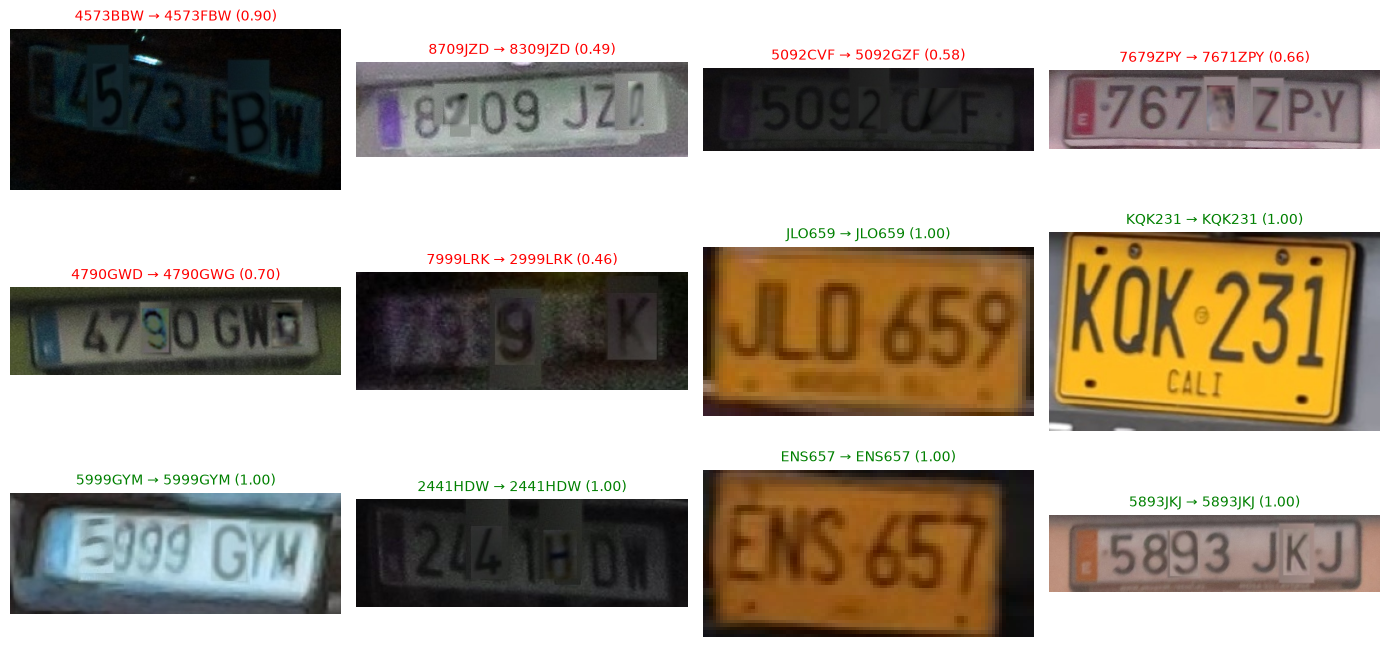

fuente
colombia    0.978723
uc3m        0.935185
Name: placa_exacta, dtype: float64

In [16]:
frame = pd.read_csv(DATASET_DIR / "dataset.csv", dtype=str)
frame = frame[frame["split"] == "test"].reset_index(drop=True)
lecturas = [leer_placa_tflite(DATASET_DIR / r, con_confianza=True) for r in frame["image_path"]]
frame["lectura"] = [texto for texto, _ in lecturas]
frame["confianza_min"] = [float(conf[:max(1, len(texto))].min()) for texto, conf in lecturas]
frame["ok"] = frame["lectura"] == frame["plate_text"]
muestra = pd.concat([frame[~frame["ok"]].head(6), frame[frame["ok"]].sample(min(6, frame["ok"].sum()), random_state=SEED)])

fig, axes = plt.subplots(3, 4, figsize=(14, 7))
for ax in axes.flat:
    ax.axis("off")
for ax, fila in zip(axes.flat, muestra.itertuples()):
    ax.imshow(Image.open(DATASET_DIR / fila.image_path).convert("RGB"))
    ax.set_title(f"{fila.plate_text} → {fila.lectura} ({fila.confianza_min:.2f})",
                 color="green" if fila.ok else "red", fontsize=10)
plt.tight_layout()
plt.show()
display(frame.groupby("fuente")["ok"].mean().rename("placa_exacta"))

El `.tflite` y su `plate_config.yaml` son lo que necesita la app para leer una placa ya recortada por el detector:
entrada `[1, alto, ancho, 3]` float32 en RGB (0–255), con el tamaño de su `plate_config.yaml` (`IMG_SIZE`), y, en la salida, el carácter más probable de cada posición sin el
relleno `_`. El ONNX se puede usar en el pipeline de Python con
`LicensePlateRecognizer(onnx_model_path=ONNX_PATH, plate_config_path=EXPORT_DIR / "plate_config.yaml")`.